---

### 동작 과정

```txt
Python 객체(messages)
        ↓
json.dumps()
        ↓
JSON 문자열 생성
        ↓
Path.write_text()
        ↓
JSON 파일 저장
        ↓
Path.read_text()
```

In [1]:
# JSON 파일 입출력을 위한 표준 라이브러리
import json

# 파일 경로를 객체 형태로 다루기 위한 라이브러리
from pathlib import Path

# Path는 파일 경로를 객체 형태로 다루기 위한 클래스입니다.
# JSON 파일의 경로를 Path 객체로 만들어 DB_FILE 변수에 저장합니다.
DB_FILE = Path("./sample.json")

 ---
JSON 파일 초기화
- 파일이 없다면 빈 JSON 배열([])을 만들어 파일을 생성합니다.
- json.dumps()은 Python 객체 → JSON 문자열로 변환합니다.

    ```txt
    예) json.dumps([1,2,3]) -> "[1, 2, 3]"
        json.dumps([])      -> "[]"
    ```

In [3]:
if not DB_FILE.exists():
    DB_FILE.write_text(json.dumps([]))

 ---
리스트에 데이터 저장

In [4]:
messages = []

messages.append({"role": "user", "content": "안녕하세요"})

 ---
## json.dumps(messages, ensure_ascii=False, indent=2)
### 1. json.dumps()

- `json.dumps()` : Python 객체를 JSON 문자열(JSON String)로 변환하는 함수입니다.

    - 예)

        ```python
        import json
        data = {"msg": "hello"}
        json_text = json.dumps(data)
        ```

 ---
### 2. ensure_ascii 옵션

JSON은 기본적으로 **ASCII 문자만 사용하도록 설계되어 있기 때문에** 한글과 같은 문자는 **Unicode 형태로 변환되어 저장됩니다.**

- 예)
    ```python
    data = {"msg": "안녕하세요"}
    ```

#### (1) ensure_ascii=True (기본값)

```python
json.dumps(data)
```

저장 결과

```json
{"msg": "\uc548\ub155\ud558\uc138\uc694"}
```
→ 한글이 **Unicode 형태**로 저장됩니다.

 ---
#### (2) ensure_ascii=False

```python
json.dumps(data, ensure_ascii=False)
```

저장 결과

```json
{"msg": "안녕하세요"}
```

→ 한글이 **그대로 저장됩니다.**

일반적으로 **한국어 데이터를 저장할 때는 `ensure_ascii=False`를 사용합니다.**

---

### 3. indent 옵션

`indent` 옵션은 JSON **사람이 읽기 쉽도록 들여쓰기(formatting)** 해서 저장하는 옵션입니다.

#### indent 없는 경우

```json
[{"role":"assistant","content":"hello"}]
```

---


indent=2 사용

```json
[
  {
    "role": "assistant",
    "content": "hello"
  }
]
```

→ 구조가 **계층적으로 보기 쉬워집니다.**

---

| 옵션 | 역할 |
| :--- | :--- |
| `ensure_ascii=False` | 한글을 Unicode가 아니라 그대로 저장 |
| `indent=2` | JSON을 사람이 읽기 쉽게 들여쓰기 |

 ---
Python 리스트 → JSON 문자열로 변환

In [5]:
json_text = json.dumps(messages, ensure_ascii=False, indent=2)

 ---
JSON 파일 저장

- write_text() : 문자열 데이터를 파일에 저장합니다.

- encoding="utf-8" : 한글이 깨지지 않도록 UTF-8 인코딩으로 저장합니다.

In [6]:
DB_FILE.write_text(
    json_text,
    encoding="utf-8"
)

54

- 54는 파일에 저장된 문자열 길이입니다.
주피터 노트북은 코드 셀의 가장 마지막 줄에 있는 값이나 표현식의 결과를 명시적인 print() 함수 없이도 화면에 보여줍니다.

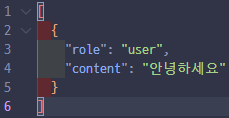

---

JSON 파일 내용 읽기

In [7]:
# JSON 파일 내용을 문자열로 읽기
text = DB_FILE.read_text(encoding="utf-8")

print(text)

[
  {
    "role": "user",
    "content": "안녕하세요"
  }
]


 ---
ensure_ascii=True 로 변경

In [8]:
json_text2 = json.dumps(messages, ensure_ascii=True, indent=2)

DB_FILE.write_text(
    json_text2,
    encoding="utf-8"
)

79

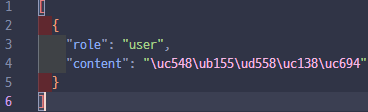

In [9]:
text = DB_FILE.read_text(encoding="utf-8")

print(text)

[
  {
    "role": "user",
    "content": "\uc548\ub155\ud558\uc138\uc694"
  }
]


 ---
JSON을 Python 객체로 변환합니다.

In [10]:
import json

In [11]:
# JSON을 Python 객체로 변환합니다.
data = json.loads(text)
print(type(data))
print(data)

<class 'list'>
[{'role': 'user', 'content': '안녕하세요'}]
